In [82]:

import os
import json
import warnings
import zipfile
import shutil
import math
warnings.filterwarnings("ignore")



import numpy as np
import pandas as pd
import joblib



from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix



from xgboost import XGBClassifier
from lightgbm import LGBMClassifier



import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks



import shap



RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(" Imports loaded successfully!")

 Imports loaded successfully!


In [83]:


BASE_DIR = "/content"
DATA_PATH = os.path.join(BASE_DIR, "Thyroid_Diff.csv")
MODEL_DIR = os.path.join(BASE_DIR, "models")



os.makedirs(MODEL_DIR, exist_ok=True)
print(f"Data path: {DATA_PATH}")
print(f"Model directory: {MODEL_DIR}")



Data path: /content/Thyroid_Diff.csv
Model directory: /content/models


### Basic analysis  of data

In [84]:
df = pd.read_csv(DATA_PATH)


In [85]:
print(df.shape)


(383, 17)


In [86]:
print(df.columns.tolist())

['Age', 'Gender', 'Smoking', 'Hx Smoking', 'Hx Radiothreapy', 'Thyroid Function', 'Physical Examination', 'Adenopathy', 'Pathology', 'Focality', 'Risk', 'T', 'N', 'M', 'Stage', 'Response', 'Recurred']


In [87]:
print(df.head())

   Age Gender Smoking Hx Smoking Hx Radiothreapy Thyroid Function  \
0   27      F      No         No              No        Euthyroid   
1   34      F      No        Yes              No        Euthyroid   
2   30      F      No         No              No        Euthyroid   
3   62      F      No         No              No        Euthyroid   
4   62      F      No         No              No        Euthyroid   

          Physical Examination Adenopathy       Pathology     Focality Risk  \
0   Single nodular goiter-left         No  Micropapillary    Uni-Focal  Low   
1          Multinodular goiter         No  Micropapillary    Uni-Focal  Low   
2  Single nodular goiter-right         No  Micropapillary    Uni-Focal  Low   
3  Single nodular goiter-right         No  Micropapillary    Uni-Focal  Low   
4          Multinodular goiter         No  Micropapillary  Multi-Focal  Low   

     T   N   M Stage       Response Recurred  
0  T1a  N0  M0     I  Indeterminate       No  
1  T1a  N0  M0  

In [88]:
print(df.isnull().sum())

Age                     0
Gender                  0
Smoking                 0
Hx Smoking              0
Hx Radiothreapy         0
Thyroid Function        0
Physical Examination    0
Adenopathy              0
Pathology               0
Focality                0
Risk                    0
T                       0
N                       0
M                       0
Stage                   0
Response                0
Recurred                0
dtype: int64


In [89]:
print(df.duplicated().sum())

19


In [90]:
print(df.describe())

              Age
count  383.000000
mean    40.866841
std     15.134494
min     15.000000
25%     29.000000
50%     37.000000
75%     51.000000
max     82.000000


In [91]:







print(df.describe(include='object'))

       Gender Smoking Hx Smoking Hx Radiothreapy Thyroid Function  \
count     383     383        383             383              383   
unique      2       2          2               2                5   
top         F      No         No              No        Euthyroid   
freq      312     334        355             376              332   

       Physical Examination Adenopathy  Pathology   Focality Risk    T    N  \
count                   383        383        383        383  383  383  383   
unique                    5          6          4          2    3    7    3   
top     Multinodular goiter         No  Papillary  Uni-Focal  Low   T2   N0   
freq                    140        277        287        247  249  151  268   

          M Stage   Response Recurred  
count   383   383        383      383  
unique    2     5          4        2  
top      M0     I  Excellent       No  
freq    365   333        208      275  


### class distribution

In [92]:
target_col = df.columns[-1]

print(f"\nTarget Column: {target_col}")
print(df[target_col].value_counts())




Target Column: Recurred
Recurred
No     275
Yes    108
Name: count, dtype: int64


In [93]:
print("\nPercentage Distribution:")
print(df[target_col].value_counts(normalize=True) * 100)


Percentage Distribution:
Recurred
No     71.801567
Yes    28.198433
Name: proportion, dtype: float64


### categorical feature analysis

In [94]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:

    print(f"Column: {col}")
    print(df[col].value_counts())

Column: Gender
Gender
F    312
M     71
Name: count, dtype: int64
Column: Smoking
Smoking
No     334
Yes     49
Name: count, dtype: int64
Column: Hx Smoking
Hx Smoking
No     355
Yes     28
Name: count, dtype: int64
Column: Hx Radiothreapy
Hx Radiothreapy
No     376
Yes      7
Name: count, dtype: int64
Column: Thyroid Function
Thyroid Function
Euthyroid                      332
Clinical Hyperthyroidism        20
Subclinical Hypothyroidism      14
Clinical Hypothyroidism         12
Subclinical Hyperthyroidism      5
Name: count, dtype: int64
Column: Physical Examination
Physical Examination
Multinodular goiter            140
Single nodular goiter-right    140
Single nodular goiter-left      89
Normal                           7
Diffuse goiter                   7
Name: count, dtype: int64
Column: Adenopathy
Adenopathy
No           277
Right         48
Bilateral     32
Left          17
Extensive      7
Posterior      2
Name: count, dtype: int64
Column: Pathology
Pathology
Papillary       

In [95]:
TARGET_COL = "Recurred"

print(f" Loaded {df.shape[0]} rows, {df.shape[1]} columns")



assert TARGET_COL in df.columns, f"Target column '{TARGET_COL}' not found"
assert df.shape[0] > 0, "Dataset is empty"



duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count}")
print(f"Target classes: {df[TARGET_COL].unique().tolist()}")
print(f"Class balance:\n{df[TARGET_COL].value_counts()}")

display(df.head())

 Loaded 383 rows, 17 columns
Duplicate rows: 19
Target classes: ['No', 'Yes']
Class balance:
Recurred
No     275
Yes    108
Name: count, dtype: int64


,Age,Gender,Smoking,Hx Smoking,Hx Radiothreapy,Thyroid Function,Physical Examination,Adenopathy,Pathology,Focality,Risk,T,N,M,Stage,Response,Recurred
0,27,F,No,No,No,Euthyroid,Single nodular goiter-left,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Indeterminate,No
1,34,F,No,Yes,No,Euthyroid,Multinodular goiter,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
2,30,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
3,62,F,No,No,No,Euthyroid,Single nodular goiter-right,No,Micropapillary,Uni-Focal,Low,T1a,N0,M0,I,Excellent,No
4,62,F,No,No,No,Euthyroid,Multinodular goiter,No,Micropapillary,Multi-Focal,Low,T1a,N0,M0,I,Excellent,No


What This Cell Does:
Purpose: Loads the dataset and performs initial validation.

Key Decisions & Rationale:

TARGET_COL = "Recurred" - Defines the target column for prediction

assert statements - Fail-fast approach: if data is invalid, stop immediately rather than continuing with errors

Duplicate detection - Identifies duplicate rows to understand data quality

Class balance display - Shows distribution of target classes (important for imbalanced classification)

df.head() - Quick visual inspection of data structure

### Re cheek missing value

In [96]:

missing_total = df.isnull().sum().sum()
print(f"Missing values found: {missing_total}")



if missing_total > 0:
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].fillna(df[c].mode()[0])
        else:
            df[c] = df[c].fillna(df[c].median())
    print("Missing")

else:

    print("clean.")

Missing values found: 0
clean.


What This Cell Does:
Purpose: Handles any missing values in the dataset.

Key Decisions & Rationale:

Different strategies for different data types:

Categorical (object dtype) - Uses mode (most frequent value). Why? The mode is the most common category, which is a reasonable guess.

Numeric - Uses median (middle value). Why? Median is robust to outliers (unlike mean which can be skewed by extreme values).

Why not just drop rows? - With only 383 rows, dropping rows could lose valuable data. Imputation preserves the dataset size.

Checks for missing values first - Avoids unnecessary operations if data is already clean.

## Data Preprocessing: Feature Encoding and Scaling

In [97]:

feature_cols = [c for c in df.columns if c != TARGET_COL]
numeric_features = ["Age"]
categorical_features = [c for c in feature_cols if c not in numeric_features]



target_encoder = LabelEncoder()
y = target_encoder.fit_transform(df[TARGET_COL])  # No=0, Yes=1
X = df[feature_cols].copy()



X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")



preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)



preprocessor.fit(X_train)
X_train_t = preprocessor.transform(X_train)
X_test_t = preprocessor.transform(X_test)
print(f"Encoded feature dimensionality: {X_train_t.shape[1]}")

Train: (306, 16), Test: (77, 16)
Encoded feature dimensionality: 55


What This Cell Does:
Purpose: Prepares features for machine learning models.

Key Decisions & Rationale:

Target encoding - LabelEncoder converts "No"→0, "Yes"→1 (required for binary classification)

Stratified split - stratify=y preserves class distribution in both train and test sets (critical for imbalanced data)

80/20 split - Standard practice (more training data = better models)

ColumnTransformer - Applies different transformations to different column types:

StandardScaler for Age - Standardizes to mean=0, std=1. Why? Many ML algorithms (SVM, Logistic Regression) are sensitive to feature scales.

OneHotEncoder for categorical - Converts categories to binary vectors. Why? ML models require numeric inputs.

handle_unknown="ignore" - Handles unseen categories in test data without crashing

preprocessor.fit(X_train) then transform both - Prevents data leakage (using test data to fit the transformer)

##  Model training + evaluation

In [98]:

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()



sk_models = {
    "Logistic Regression": LogisticRegression(
      max_iter=2000,
      class_weight="balanced",
      random_state=RANDOM_STATE
      ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=6, class_weight="balanced",
        random_state=RANDOM_STATE
        ),
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        class_weight="balanced",
        random_state=RANDOM_STATE
        ),
    "KNN": KNeighborsClassifier(
        n_neighbors=7
        ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=3,
        random_state=RANDOM_STATE
        ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        eval_metric="logloss",

        random_state=RANDOM_STATE,
        scale_pos_weight=pos_weight
        ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,

        random_state=RANDOM_STATE,
        class_weight="balanced",
        verbosity=-1
        ),
}




skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
fitted_models = {}
roc_curves = {}





for name, model in sk_models.items():
    cv_scores = cross_val_score(model, X_train_t, y_train, cv=skf, scoring="roc_auc")
    model.fit(X_train_t, y_train)
    y_pred = model.predict(X_test_t)
    y_proba = model.predict_proba(X_test_t)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_curves[name] = {"fpr": fpr.tolist(), "tpr": tpr.tolist()}

    metrics = {
        "model": name,
        "type": "ML",
        "cv_roc_auc_mean": float(cv_scores.mean()),
        "cv_roc_auc_std": float(cv_scores.std()),
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred)),
        "recall": float(recall_score(y_test, y_pred)),
        "f1": float(f1_score(y_test, y_pred)),
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
    }




    results.append(metrics)
    fitted_models[name] = model
    print(f"{name:22s} | Acc {metrics['accuracy']:.4f} | F1 {metrics['f1']:.4f} | ROC-AUC {metrics['roc_auc']:.4f}")

Logistic Regression    | Acc 0.9610 | F1 0.9302 | ROC-AUC 0.9917
Random Forest          | Acc 0.9610 | F1 0.9268 | ROC-AUC 0.9950
SVM                    | Acc 0.9610 | F1 0.9302 | ROC-AUC 0.9843
KNN                    | Acc 0.9481 | F1 0.9048 | ROC-AUC 0.9851
Gradient Boosting      | Acc 0.9610 | F1 0.9268 | ROC-AUC 0.9851
XGBoost                | Acc 0.9610 | F1 0.9333 | ROC-AUC 0.9917
LightGBM               | Acc 0.9481 | F1 0.9130 | ROC-AUC 0.9934


What This Cell Does:
Purpose: Trains and evaluates 7 different ML models.

Key Decisions & Rationale:

pos_weight - Computes the ratio of negative to positive samples (used for XGBoost's scale_pos_weight parameter)

Model Selection Rationale:

Logistic Regression - Baseline model, interpretable, fast

Random Forest - Ensemble of decision trees, handles non-linear relationships well

SVM with RBF kernel - Powerful for non-linear classification

KNN - Simple instance-based learning

Gradient Boosting - Sequential boosting, often high performance

XGBoost - Regularized boosting, handles imbalanced data with scale_pos_weight

LightGBM - Fast gradient boosting, efficient with class_weight="balanced"

Hyperparameter choices:

class_weight="balanced" - Automatically adjusts weights for imbalanced classes (important for rare event prediction)

n_estimators=300 - More trees = better performance (diminishing returns after certain point)

max_depth=6 for Random Forest - Prevents overfitting on small dataset

learning_rate=0.05 - Small learning rate for gradual learning

Cross-validation - 5-fold stratified CV gives more reliable performance estimates

ROC-AUC scoring - Better for imbalanced classification than accuracy

Stores predictions and probabilities - For ROC curves and later analysis

## Training Deep Learning model: TensorFlow/Keras ANN

In [99]:


n_features = X_train_t.shape[1]
class_weight_dict = {0: 1.0, 1: float(pos_weight)}



ann = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid"),
])
ann.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
            loss="binary_crossentropy",
            metrics=["accuracy", keras.metrics.AUC(name="auc")])



early_stop = callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=25,

    restore_best_weights=True)



X_train_dense = X_train_t.toarray() if hasattr(X_train_t, "toarray") else X_train_t
X_test_dense = X_test_t.toarray() if hasattr(X_test_t, "toarray") else X_test_t

history = ann.fit(
    X_train_dense, y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=16,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1,
)



y_proba_ann = ann.predict(X_test_dense, verbose=0).ravel()
y_pred_ann = (y_proba_ann >= 0.5).astype(int)
fpr, tpr, _ = roc_curve(y_test, y_proba_ann)
roc_curves["Neural Network (Keras ANN)"] = {"fpr": fpr.tolist(), "tpr": tpr.tolist()}



ann_metrics = {
    "model": "Neural Network (Keras ANN)",
    "type": "DL",
    "cv_roc_auc_mean": None,
    "cv_roc_auc_std": None,
    "accuracy": float(accuracy_score(y_test, y_pred_ann)),
    "precision": float(precision_score(y_test, y_pred_ann)),
    "recall": float(recall_score(y_test, y_pred_ann)),
    "f1": float(f1_score(y_test, y_pred_ann)),
    "roc_auc": float(roc_auc_score(y_test, y_proba_ann)),
}
results.append(ann_metrics)
print(f"{'Neural Network (ANN)':22s} | Acc {ann_metrics['accuracy']:.4f} | F1 {ann_metrics['f1']:.4f} | ROC-AUC {ann_metrics['roc_auc']:.4f} | epochs run: {len(history.history['loss'])}")

Epoch 1/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.6926 - auc: 0.7171 - loss: 0.9372 - val_accuracy: 0.8710 - val_auc: 0.9429 - val_loss: 0.5377
Epoch 2/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8934 - auc: 0.9460 - loss: 0.6768 - val_accuracy: 0.8871 - val_auc: 0.9457 - val_loss: 0.3621
Epoch 3/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8811 - auc: 0.9487 - loss: 0.4944 - val_accuracy: 0.8387 - val_auc: 0.9558 - val_loss: 0.3415
Epoch 4/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9098 - auc: 0.9728 - loss: 0.3248 - val_accuracy: 0.9032 - val_auc: 0.9701 - val_loss: 0.2200
Epoch 5/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9057 - auc: 0.9747 - loss: 0.3095 - val_accuracy: 0.9032 - val_auc: 0.9742 - val_loss: 0.2720
Epoch 6/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9426 - auc: 0.9881 - loss: 0.2199 - val_accuracy: 0.9032 - val_auc: 0.9837 - val_loss: 0.1797
Epoch 7/300
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms

Neural Network (ANN)   | Acc 0.9740 | F1 0.9545 | ROC-AUC 0.9926 | epochs run: 54


What This Cell Does:
Purpose: Builds, trains, and evaluates a deep neural network.

Key Decisions & Rationale:

Architecture (128 → 64 → 32 → 1) - Decreasing layers allow the network to learn hierarchical features:

First layer: 128 neurons (captures complex interactions)

Second layer: 64 neurons (compresses features)

Third layer: 32 neurons (further abstraction)

Output layer: 1 neuron with sigmoid (binary classification)

Dropout layers (0.3, 0.2) - Prevents overfitting by randomly dropping neurons during training

ReLU activation - Non-linear activation, avoids vanishing gradient problem

Sigmoid output - Outputs probability between 0 and 1 (perfect for binary classification)

Adam optimizer with learning_rate=1e-3 - Adaptive learning rate, good for most problems

Binary crossentropy loss - Standard for binary classification

Early stopping - patience=25 stops training when validation AUC doesn't improve for 25 epochs

Prevents overfitting

Saves time (doesn't waste epochs on no improvement)

Restores best weights automatically

Class weights - Handles imbalanced data by giving more weight to minority class

Batch size=16 - Small batch size for better generalization

Validation split=20% - Monitors performance on held-out validation data

In [100]:
results_df = pd.DataFrame(results).sort_values(
    by=["roc_auc", "f1", "recall"],
    ascending=False
).reset_index(drop=True)
results_df = results_df.where(pd.notnull(results_df), None)



print("MODEL COMPARISON ")
display(results_df)

best_row = results_df.iloc[0]
best_name = best_row["model"]
print(f"\n SELECTED BEST MODEL: {best_name}")



is_ann_best = best_name == "Neural Network (Keras ANN)"

MODEL COMPARISON 


,model,type,cv_roc_auc_mean,cv_roc_auc_std,accuracy,precision,recall,f1,roc_auc
0,Random Forest,ML,0.990909,0.008084,0.961039,1.000000,0.863636,0.926829,0.995041
1,LightGBM,ML,0.982635,0.011827,0.948052,0.875000,0.954545,0.913043,0.993388
2,Neural Network (Keras ANN),DL,NaN,NaN,0.974026,0.954545,0.954545,0.954545,0.992562
3,XGBoost,ML,0.983422,0.017607,0.961039,0.913043,0.954545,0.933333,0.991736
4,Logistic Regression,ML,0.982635,0.019201,0.961039,0.952381,0.909091,0.930233,0.991736
5,Gradient Boosting,ML,0.984789,0.012359,0.961039,1.000000,0.863636,0.926829,0.985124
6,KNN,ML,0.953877,0.034390,0.948052,0.950000,0.863636,0.904762,0.985124
7,SVM,ML,0.982903,0.020969,0.961039,0.952381,0.909091,0.930233,0.984298



 SELECTED BEST MODEL: Random Forest


What This Cell Does:
Purpose: Compares all models and selects the best one.

Key Decisions & Rationale:

Selection Priority: ROC-AUC → F1 → Recall

ROC-AUC is primary metric. Why?

Handles imbalanced data well

Doesn't require choosing a threshold

Good overall measure of model performance

F1 as second priority. Why?

Harmonic mean of precision and recall

Good balance between false positives and false negatives

Recall as third priority. Why?

In medical context, we want to catch as many recurrence cases as possible

False negatives (missing a recurrence) are worse than false positives

Sorting descending - Best model appears first

results_df.where(pd.notnull(results_df), None) - Handles NaN values cleanly

##  CLEAN METRICS FUNCTION

In [101]:



def clean_metrics(metrics_dict):

    cleaned = {}
    for key, value in metrics_dict.items():
        if isinstance(value, float):
            if math.isnan(value) or math.isinf(value):
                cleaned[key] = None
            else:

                cleaned[key] = round(value, 6)
        elif isinstance(value, dict):

            cleaned[key] = clean_metrics(value)
        elif isinstance(value, list):

            cleaned[key] = [None if (isinstance(v, float) and (math.isnan(v) or math.isinf(v))) else v for v in value]
        else:

            cleaned[key] = value

    return cleaned

What This Cell Does:
Purpose: Cleans metric dictionaries by removing NaN, Inf, and None values.

Key Decisions & Rationale:

Why needed? - Some metrics (like cross-validation scores for Neural Network) may be NaN

JSON compatibility - NaN and Inf are not valid JSON values

Recursive handling - Handles nested dictionaries and lists

Rounding - Rounds floats to 6 decimal places for cleaner output

## Save  preprocessing

In [102]:


joblib.dump(preprocessor, os.path.join(MODEL_DIR, "preprocessing.pkl"))
joblib.dump(target_encoder, os.path.join(MODEL_DIR, "target_encoder.pkl"))
print(" Saved preprocessing.pkl")
print(" Saved target_encoder.pkl")




clean_results = []
for r in results:
    clean_r = clean_metrics(r)
    clean_results.append(clean_r)

results_df_clean = pd.DataFrame(clean_results)




all_models_dir = os.path.join(MODEL_DIR, "all_models")
os.makedirs(all_models_dir, exist_ok=True)



for model_name, model in fitted_models.items():
    safe_name = model_name.replace(" ", "_").replace("/", "_")
    model_path = os.path.join(all_models_dir, f"{safe_name}.pkl")
    try:

        joblib.dump(model, model_path)
        print(f" Saved {model_name} -> {safe_name}.pkl")
    except Exception as e:

        print(f" Could not save {model_name}: {e}")

 Saved preprocessing.pkl
 Saved target_encoder.pkl
 Saved Logistic Regression -> Logistic_Regression.pkl
 Saved Random Forest -> Random_Forest.pkl
 Saved SVM -> SVM.pkl
 Saved KNN -> KNN.pkl
 Saved Gradient Boosting -> Gradient_Boosting.pkl
 Saved XGBoost -> XGBoost.pkl
 Saved LightGBM -> LightGBM.pkl


What This Cell Does:
Purpose: Saves preprocessing objects and all trained models.

Key Decisions & Rationale:

joblib vs pickle - joblib is more efficient for large numpy arrays (scikit-learn models)

Save preprocessor - Needed to transform new data during inference

Save target encoder - Needed to decode predictions back to class labels

Save all models - Allows experimenting with different models without retraining

Safe filenames - Replaces spaces and slashes to ensure valid filenames

Error handling - Continues even if one model fails to save



In [103]:

keras_path = os.path.join(MODEL_DIR, "best_model.keras")
ann.save(keras_path)
print(f" keras at: {keras_path}")





if os.path.exists(keras_path):
    print(f" best_model.keras size: {os.path.getsize(keras_path) / 1024:.2f} KB")
else:
    print(" ERROR: best_model.keras was not saved!")






weights_path = os.path.join(MODEL_DIR, "best_model.weights.h5")
ann.save_weights(weights_path)
print(f" weights.h5 at: {weights_path}")





if os.path.exists(weights_path):
    print(f" weights.h5 size: {os.path.getsize(weights_path) / 1024:.2f} KB")
else:
    print(" ERROR h5 not save ")




ann_wrapper = {
    "model_type": "keras",
    "model_path": "best_model.keras",
    "weights_path": "best_model.weights.h5",
    "class_weight": class_weight_dict,
    "feature_count": n_features,
    "metrics": ann_metrics
}
wrapper_path = os.path.join(MODEL_DIR, "best_model_keras.pkl")
joblib.dump(ann_wrapper, wrapper_path)
print(f"  best_model_keras.pkl : {wrapper_path}")




backup_dir = os.path.join(BASE_DIR, "backup_models")
os.makedirs(backup_dir, exist_ok=True)



shutil.copy2(keras_path, os.path.join(backup_dir, "best_model.keras"))
shutil.copy2(weights_path, os.path.join(backup_dir, "best_model.weights.h5"))
print(f" Backup copies saved to: {backup_dir}")

 keras at: /content/models/best_model.keras
 best_model.keras size: 239.72 KB
 weights.h5 at: /content/models/best_model.weights.h5
 weights.h5 size: 235.56 KB
  best_model_keras.pkl : /content/models/best_model_keras.pkl
 Backup copies saved to: /content/backup_models


What This Cell Does:
Purpose: ALWAYS saves the Keras model regardless of whether it's the best model.

Key Decisions & Rationale:

Always save Keras - This is the key change! Previously only saved if it was the best model

Two file formats:

best_model.keras - TensorFlow's recommended format (saves architecture + weights + optimizer state)

best_model.weights.h5 - Legacy H5 format (weights only) for compatibility

Verification - Checks that files were actually created and reports their sizes

Wrapper file - Stores additional metadata (class weights, feature count, metrics) for easy loading

Backup copies - Creates a backup folder as extra safety net

Why save both formats? - .keras is the modern format, .h5 ensures compatibility with older code

## Save best model

In [104]:

if is_ann_best:

    joblib.dump(ann_wrapper, os.path.join(MODEL_DIR, "best_model.pkl"))
    print("Saved: best_model.pkl (ANN)")
else:


    sklearn_path = os.path.join(MODEL_DIR, "best_model.pkl")
    joblib.dump(fitted_models[best_name], sklearn_path)
    print(f" Saved best_model.pkl -> {best_name} at: {sklearn_path}")




important_models = {
    "XGBoost": "xgb_model.pkl",
    "Random Forest": "random_forest_model.pkl",
    "LightGBM": "lgbm_model.pkl",
    "Logistic Regression": "logistic_regression.pkl",
    "SVM": "svm_model.pkl",
    "Gradient Boosting": "gradient_boosting.pkl",
    "KNN": "knn_model.pkl"
}

for model_name, filename in important_models.items():
    if model_name in fitted_models:
        try:

            model_path = os.path.join(MODEL_DIR, filename)
            joblib.dump(fitted_models[model_name], model_path)
            print(f" Saved {model_name} -> {filename}")
        except Exception as e:

            print(f" Could not save {model_name}: {e}")



if 'X_train_dense' in locals():
    background_idx = np.random.RandomState(RANDOM_STATE).choice(
        X_train_t.shape[0], size=min(50, X_train_t.shape[0]), replace=False
    )

    X_background = X_train_dense[background_idx]
    joblib.dump(X_background, os.path.join(MODEL_DIR, "shap_background.pkl"))
    print(" Saved shap_background.pkl")

 Saved best_model.pkl -> Random Forest at: /content/models/best_model.pkl
 Saved XGBoost -> xgb_model.pkl
 Saved Random Forest -> random_forest_model.pkl
 Saved LightGBM -> lgbm_model.pkl
 Saved Logistic Regression -> logistic_regression.pkl
 Saved SVM -> svm_model.pkl
 Saved Gradient Boosting -> gradient_boosting.pkl
 Saved KNN -> knn_model.pkl
 Saved shap_background.pkl


What This Cell Does:
Purpose: Saves the best model and important individual models.

Key Decisions & Rationale:

Best model saving - Uses wrapper if Keras, direct joblib if sklearn

Individual important models - Saves each model separately for easy loading

SHAP background - Random sample of 50 training points for model interpretability

Needed for SHAP explanations

Small sample (50) keeps file size manageable

Used as "background" for SHAP KernelExplainer



## METADATA

In [105]:



categorical_options = {c: sorted(df[c].astype(str).unique().tolist()) for c in categorical_features}



if is_ann_best:

    y_pred_best = y_pred_ann
else:

    y_pred_best = fitted_models[best_name].predict(X_test_t)
cm = confusion_matrix(y_test, y_pred_best)



cm_clean = [[int(x) for x in row] for row in cm.tolist()]



model_files = {
    "best_model": "best_model.pkl",

    "best_model_keras": "best_model.keras",

    "best_model_weights": "best_model.weights.h5",

    "best_model_keras_wrapper": "best_model_keras.pkl",

    "preprocessing": "preprocessing.pkl",

    "target_encoder": "target_encoder.pkl",

    "shap_background": "shap_background.pkl"
}



for name, filename in important_models.items():
    if name in fitted_models:
        model_files[name.lower().replace(" ", "_")] = filename



metadata = {
    "best_model_name": best_name,
    "model_type": best_row["type"],
    "is_keras": bool(is_ann_best),


    "feature_cols": feature_cols,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "categorical_options": categorical_options,
    "target_classes": target_encoder.classes_.tolist(),
    "target_encoder_classes": target_encoder.classes_.tolist(),


    "dataset_info": {
        "n_samples": int(df.shape[0]),
        "n_features": len(feature_cols),
        "class_balance": df[TARGET_COL].value_counts().to_dict(),
    },


    "model_files": model_files,


    "all_models": clean_results,
    "all_model_metrics": clean_results,


    "confusion_matrix": cm_clean,
    "selection_priority": ["roc_auc", "f1", "recall"],


    "best_model_metrics": clean_metrics(best_row.to_dict()),


    "keras_model_metrics": clean_metrics(ann_metrics)
}


metadata_path = os.path.join(MODEL_DIR, "metadata.json")
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print(f" saved metadata.json at: {metadata_path}")


metrics_out = {
    "best_model": best_name,
    "best_model_metrics": clean_metrics(best_row.to_dict()),
    "selection_priority": ["roc_auc", "f1", "recall"],
    "all_models": clean_results,
    "keras_model_metrics": clean_metrics(ann_metrics)
}
metrics_path = os.path.join(MODEL_DIR, "metrics.json")
with open(metrics_path, "w") as f:
    json.dump(metrics_out, f, indent=2, default=str)
print(f" saved metrics.json at: {metrics_path}")


csv_path = os.path.join(MODEL_DIR, "model_comparison.csv")
results_df_clean.to_csv(csv_path, index=False)
print(f" saved model_comparison.csv at: {csv_path}")


roc_curves_clean = {}
for name, curve in roc_curves.items():
    roc_curves_clean[name] = {


        "fpr": [float(x) for x in curve["fpr"]],
        "tpr": [float(x) for x in curve["tpr"]]
    }



roc_path = os.path.join(MODEL_DIR, "roc_curves.json")
with open(roc_path, "w") as f:
    json.dump(roc_curves_clean, f, default=str)
print(f" saved rc.json at: {roc_path}")

 saved metadata.json at: /content/models/metadata.json
 saved metrics.json at: /content/models/metrics.json
 saved model_comparison.csv at: /content/models/model_comparison.csv
 saved rc.json at: /content/models/roc_curves.json


What This Cell Does:
Purpose: Saves comprehensive metadata about the training run.

Key Decisions & Rationale:

Complete information - Stores everything needed to understand and reproduce the results

Multiple formats - JSON (human-readable), CSV (spreadsheet compatible)

Confusion matrix - Shows performance breakdown by class

Categorical options - Pre-computed for frontend forms (dropdown options)

Feature lists - For data validation during inference

Model files list - Documents what files were saved

Keras metrics included - Even if not the best model, still included in metadata

In [106]:



for file in sorted(os.listdir(MODEL_DIR)):
    file_path = os.path.join(MODEL_DIR, file)
    if os.path.isfile(file_path):
        size = os.path.getsize(file_path) / 1024
        print(f" {file:30s} {size:8.2f} KB")
    elif os.path.isdir(file_path):
        print(f" {file:30s} {'(directory)'}")





keras_file = os.path.join(MODEL_DIR, "best_model.keras")
if os.path.exists(keras_file):
    print(f"\n keras exists at {keras_file}")
    print(f"   File size: {os.path.getsize(keras_file) / 1024:.2f} KB")

else:

    print(f"\n keras NOT FOUND at {keras_file}")


weights_file = os.path.join(MODEL_DIR, "best_model.weights.h5")
if os.path.exists(weights_file):
    print(f" h5 exists at {weights_file}")
    print(f"   File size: {os.path.getsize(weights_file) / 1024:.2f} KB")

else:
    print(f" .h5 NOT FOUND at {weights_file}")

 all_models                     (directory)
 best_model.keras                 239.72 KB
 best_model.pkl                  1063.45 KB
 best_model.weights.h5            235.56 KB
 best_model_keras.pkl               0.35 KB
 gradient_boosting.pkl            256.34 KB
 knn_model.pkl                     62.00 KB
 lgbm_model.pkl                   329.10 KB
 logistic_regression.pkl            1.30 KB
 metadata.json                      7.63 KB
 metrics.json                       2.68 KB
 model_comparison.csv               0.66 KB
 preprocessing.pkl                  6.18 KB
 random_forest_model.pkl         1063.45 KB
 roc_curves.json                    2.61 KB
 shap_background.pkl               21.70 KB
 svm_model.pkl                     27.04 KB
 target_encoder.pkl                 0.47 KB
 xgb_model.pkl                    324.96 KB

 keras exists at /content/models/best_model.keras
   File size: 239.72 KB
 h5 exists at /content/models/best_model.weights.h5
   File size: 235.56 KB


# Visualization

In [107]:



import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE



plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
sns.set_context("notebook", font_scale=1.2)



OUT_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(OUT_DIR, exist_ok=True)

In [108]:
print(f"Plots will be saved to: {OUT_DIR}")

Plots will be saved to: /content/plots


### Target Distribution Analysis

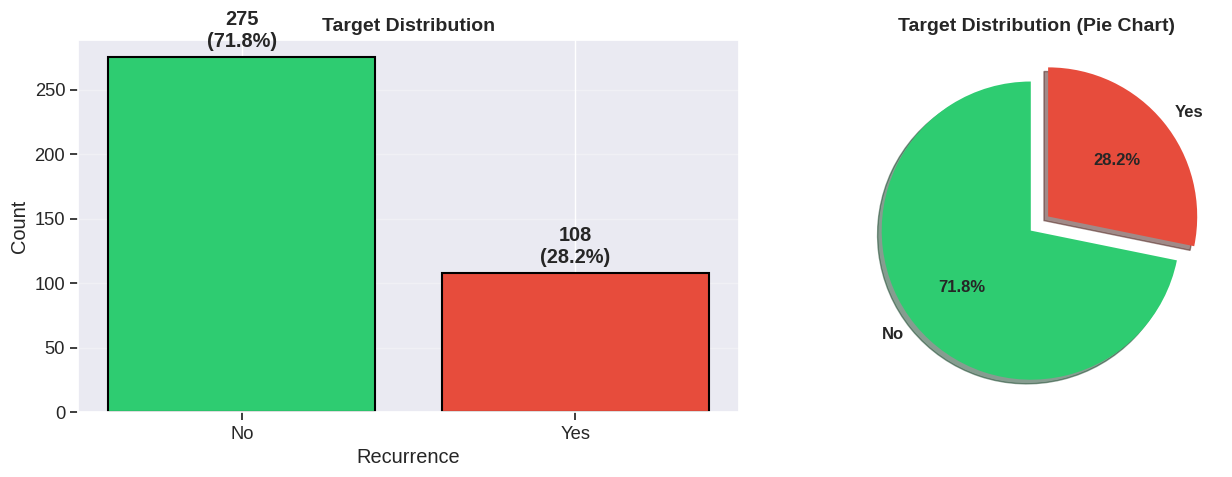

In [109]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


ax1 = axes[0]
counts = df[TARGET_COL].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = ax1.bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=1.5)
ax1.set_title('Target Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Recurrence')
ax1.set_ylabel('Count')
ax1.grid(axis='y', alpha=0.3)

total = len(df)
for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    percentage = (count/total)*100
    ax1.text(bar.get_x() + bar.get_width()/2., height + 5,
             f'{count}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontweight='bold')


ax2 = axes[1]
explode = (0.05, 0.1)
wedges, texts, autotexts = ax2.pie(counts.values,
                                   labels=counts.index,
                                   autopct='%1.1f%%',
                                   colors=colors,
                                   explode=explode,
                                   shadow=True,
                                   startangle=90,
                                   textprops={'fontsize': 12, 'weight': 'bold'})
ax2.set_title('Target Distribution (Pie Chart)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/1_target_distribution.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


### Age Distribution Analysis

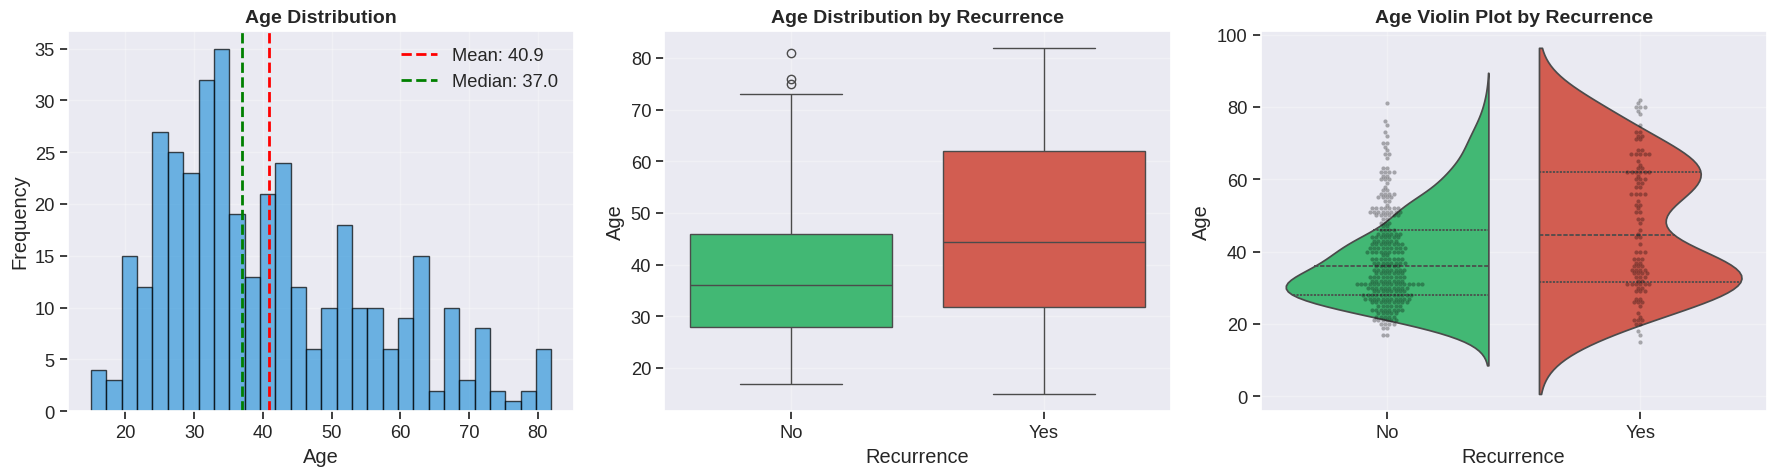

In [110]:




fig, axes = plt.subplots(1, 3, figsize=(18, 5))


ax1 = axes[0]
df['Age'].hist(bins=30, edgecolor='black', alpha=0.7, color='#3498db', ax=ax1)
ax1.axvline(df['Age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["Age"].mean():.1f}')
ax1.axvline(df['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["Age"].median():.1f}')
ax1.set_title('Age Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age')
ax1.set_ylabel('Frequency')
ax1.legend()
ax1.grid(alpha=0.3)


ax2 = axes[1]
sns.boxplot(x=TARGET_COL, y='Age', data=df, palette=['#2ecc71', '#e74c3c'], ax=ax2)
ax2.set_title('Age Distribution by Recurrence', fontsize=14, fontweight='bold')
ax2.set_xlabel('Recurrence')
ax2.set_ylabel('Age')
ax2.grid(alpha=0.3)


ax3 = axes[2]
sns.violinplot(x=TARGET_COL, y='Age', data=df, palette=['#2ecc71', '#e74c3c'],
               split=True, inner='quartile', ax=ax3)
sns.swarmplot(x=TARGET_COL, y='Age', data=df, color='black', alpha=0.3, size=3, ax=ax3)
ax3.set_title('Age Violin Plot by Recurrence', fontsize=14, fontweight='bold')
ax3.set_xlabel('Recurrence')
ax3.set_ylabel('Age')
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/2_age_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

What This Cell Does:
Purpose: Creates visualizations for target distribution and age analysis.

Key Decisions & Rationale:

Seaborn style - Professional-looking plots with seaborn-v0_8-darkgrid

High resolution - 300 DPI for publication-ready images

Green/Red colors - Intuitive: No recurrence (green = good), Recurrence (red = bad)

Target distribution:

Bar chart with percentages - Shows class imbalance clearly

Pie chart - Alternative visualization

Age analysis (3 plots):

Histogram - Shows overall age distribution with mean and median
Box plot - Compares age distribution between classes
Violin + swarm - Shows distribution shape and individual data points
Why multiple plots? - Different perspectives on the same data



### Categorical Features Analysis

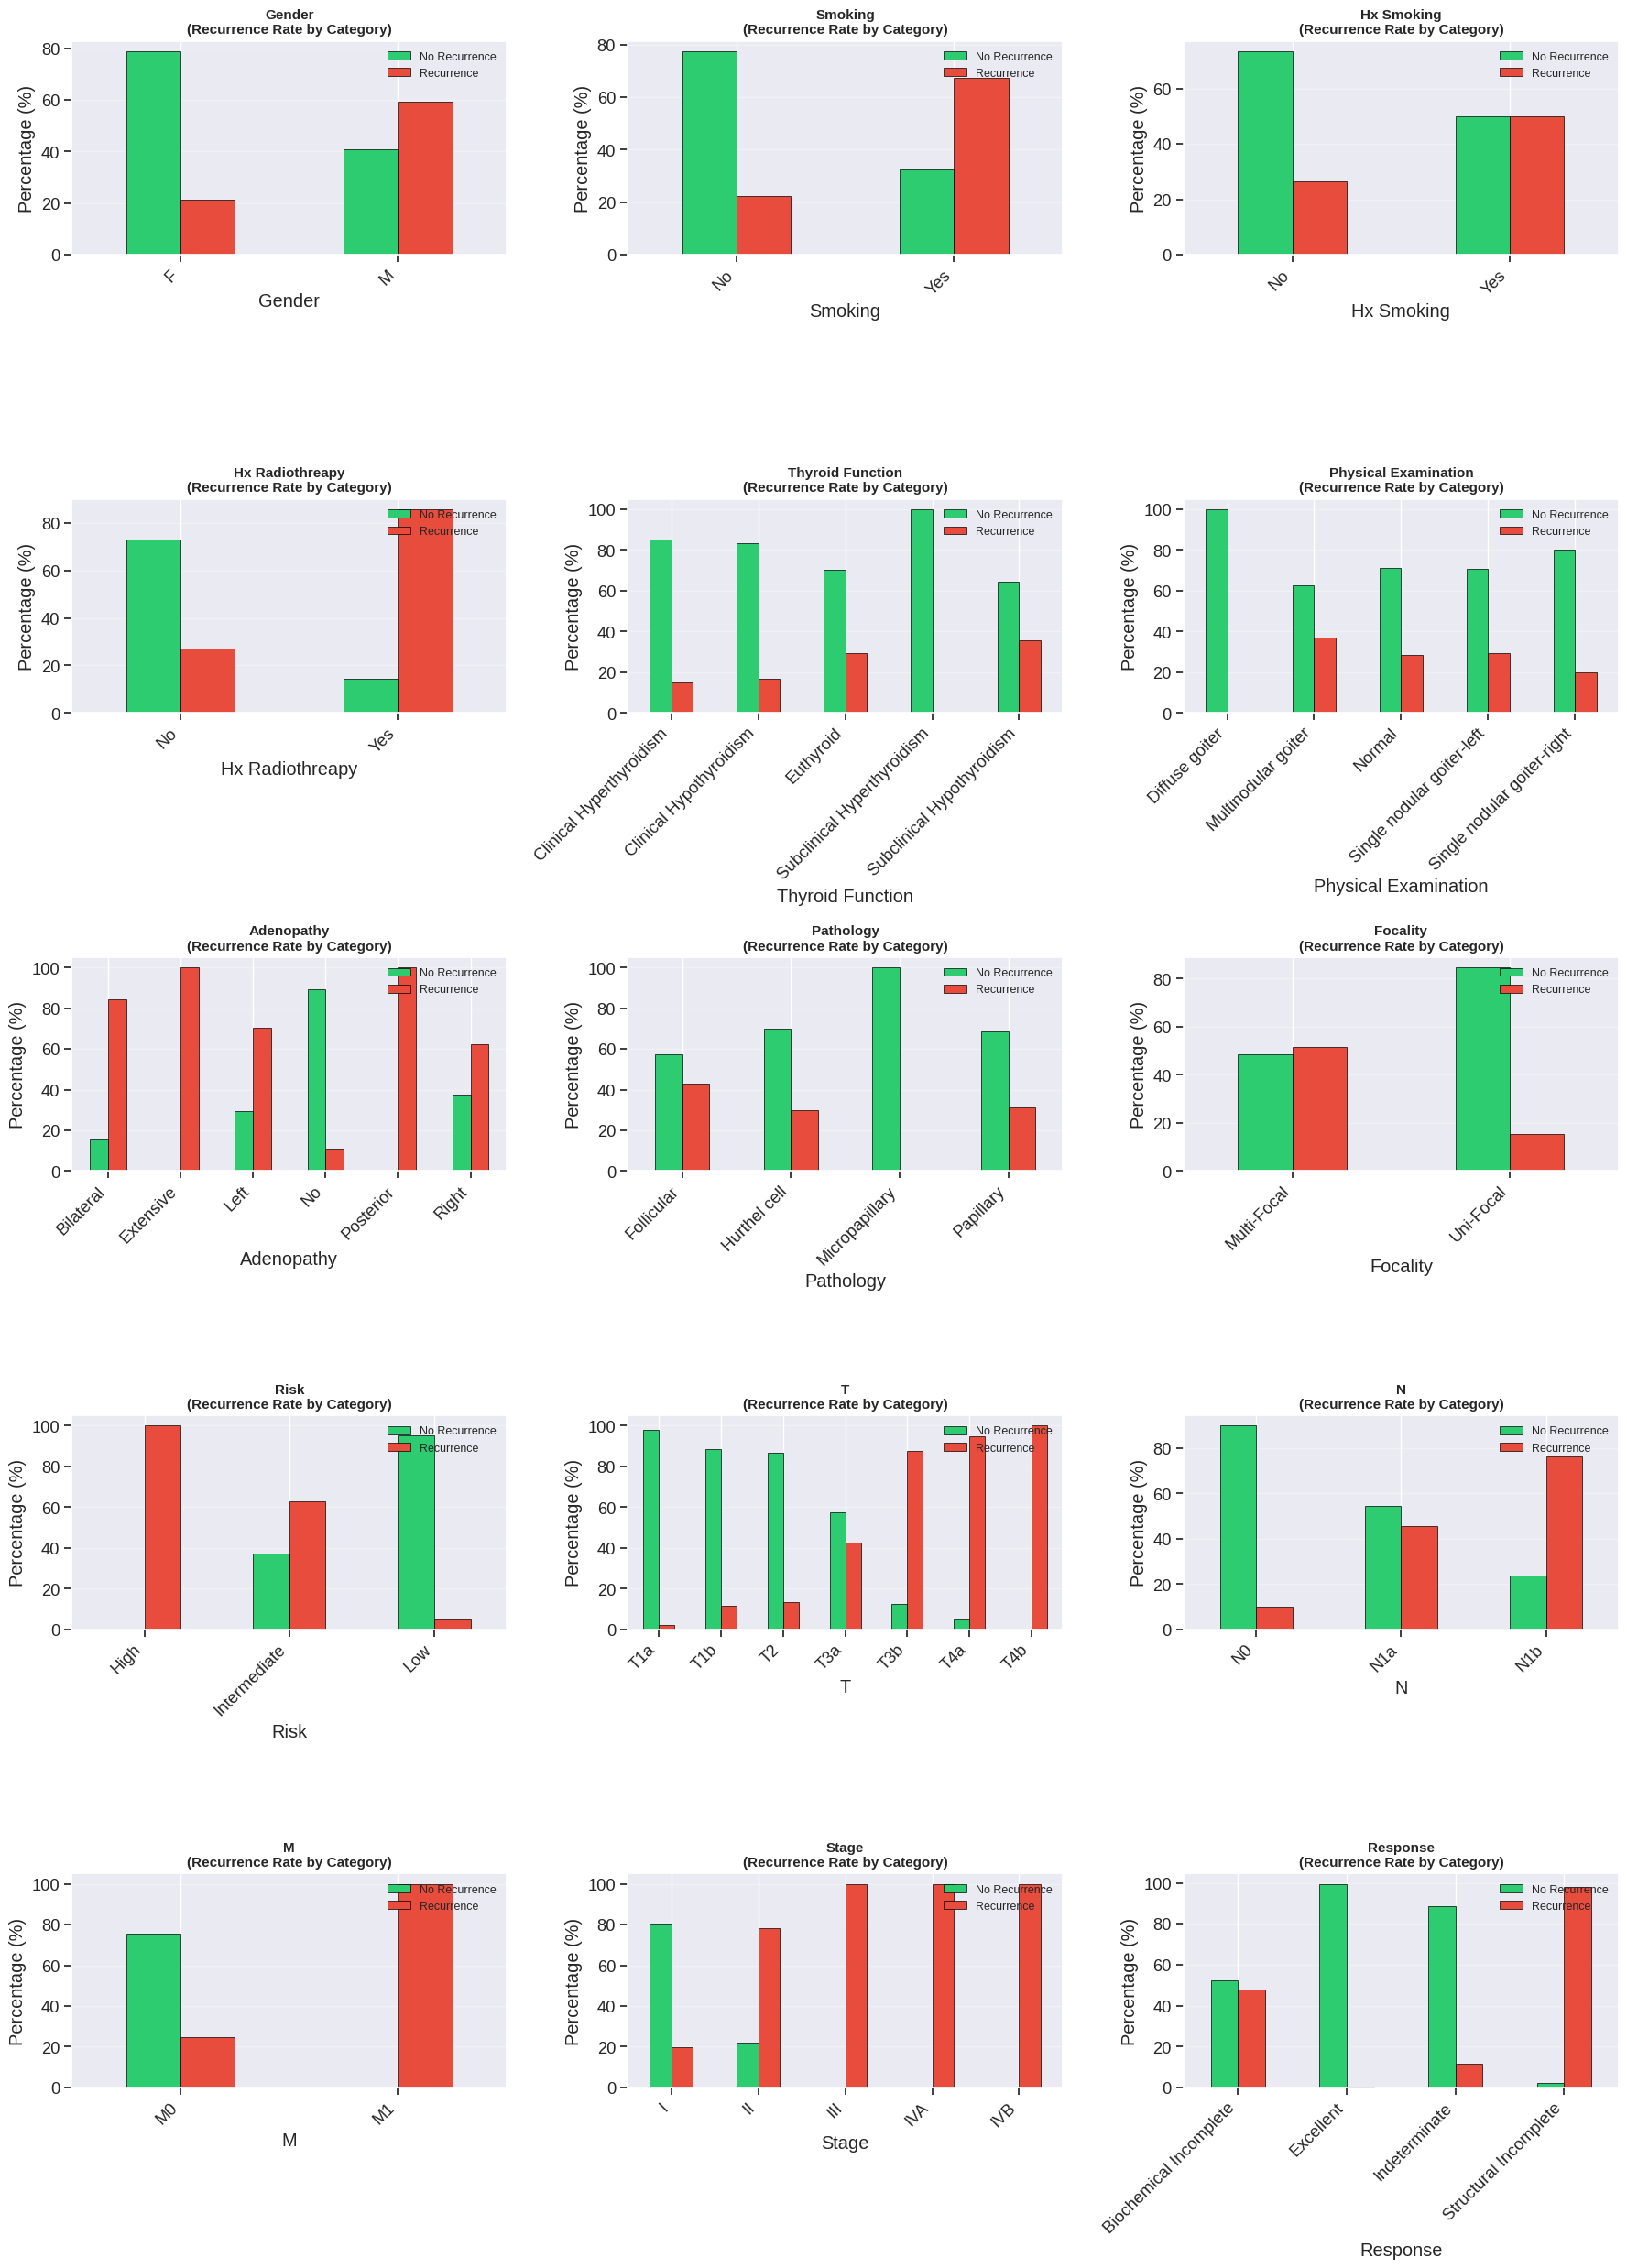

In [111]:

categorical_cols = [c for c in df.columns if c not in ['Age', TARGET_COL] and df[c].dtype == 'object']


n_cols = 3
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5*n_rows))
axes = axes.flatten()


for idx, col in enumerate(categorical_cols):
    if idx < len(axes):
        ax = axes[idx]
        crosstab = pd.crosstab(df[col], df[TARGET_COL], normalize='index') * 100
        crosstab.plot(kind='bar', ax=ax, color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
        ax.set_title(f'{col}\n(Recurrence Rate by Category)', fontsize=11, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Percentage (%)')
        ax.legend(['No Recurrence', 'Recurrence'], loc='upper right', fontsize=9)
        ax.grid(axis='y', alpha=0.3)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

for idx in range(len(categorical_cols), len(axes)):
    axes[idx].set_visible(False)


plt.tight_layout()
plt.savefig(f"{OUT_DIR}/3_categorical_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()


### Correlation Analysis

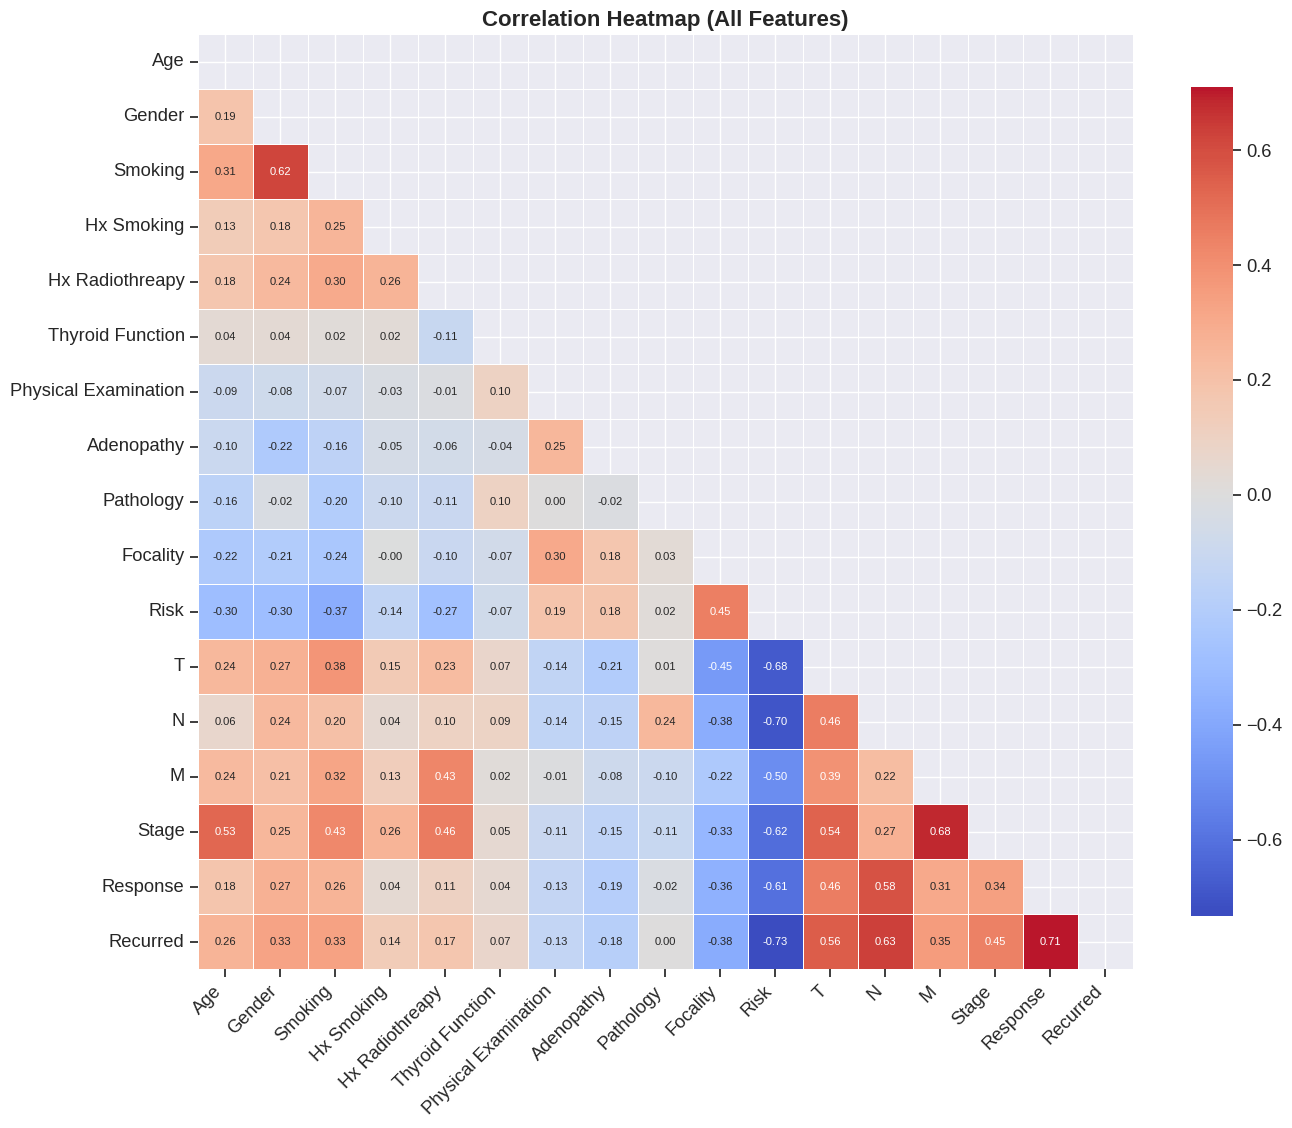

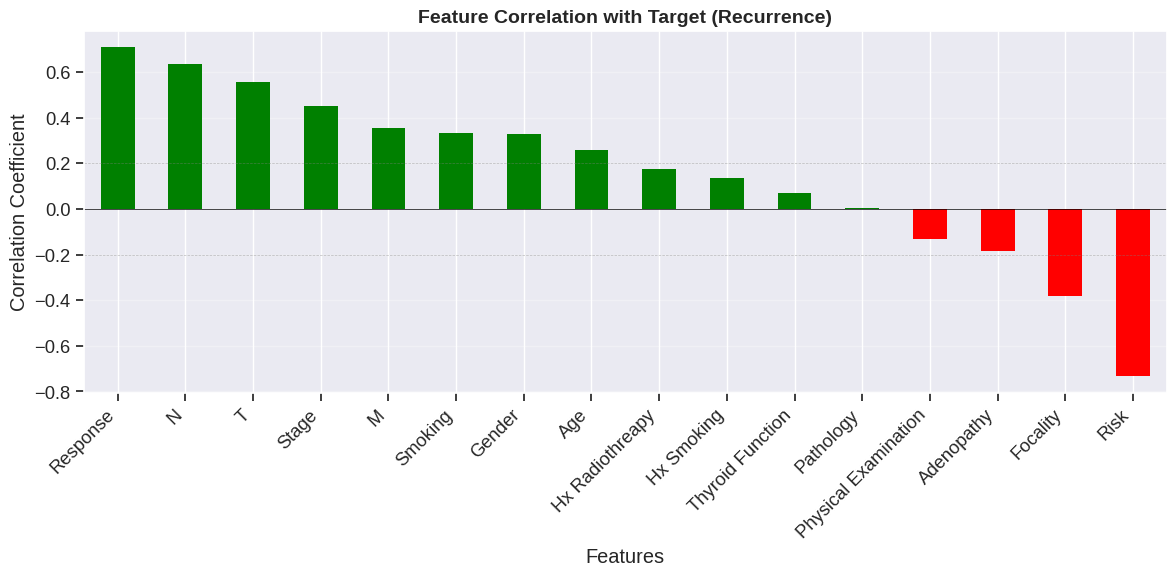

In [112]:


enc_df = df.copy()
for c in enc_df.columns:
    if not pd.api.types.is_numeric_dtype(enc_df[c]):
        enc_df[c] = LabelEncoder().fit_transform(enc_df[c].astype(str))

plt.figure(figsize=(14, 12))
correlation_matrix = enc_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})
plt.title('Correlation Heatmap (All Features)', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/4_correlation_heatmap_full.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()



corr_with_target = correlation_matrix[TARGET_COL].sort_values(ascending=False)
plt.figure(figsize=(12, 6))
colors = ['green' if x > 0 else 'red' for x in corr_with_target.drop(TARGET_COL)]
corr_with_target.drop(TARGET_COL).plot(kind='bar', color=colors)
plt.title('Feature Correlation with Target (Recurrence)', fontsize=14, fontweight='bold')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.axhline(y=0.2, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.axhline(y=-0.2, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/5_correlation_with_target.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

What This Cell Does:
Purpose: Visualizes categorical features and correlation analysis.

Key Decisions & Rationale:

Categorical features - Shows recurrence rate per category

Each plot shows percentage of recurrence vs no recurrence

Helps identify which categories are risk factors

Dynamic grid layout (3 columns, adjusts rows)

normalize='index' - Shows percentages within each category (not overall)

Correlation heatmap - Shows relationships between all features

mask=np.triu() - Shows only lower triangle (avoids redundancy)

coolwarm colormap - Red = positive correlation, Blue = negative

Annotations - Shows correlation coefficients

Correlation with target - Bar chart sorted by correlation strength

Green = positive correlation (increases recurrence risk)

Red = negative correlation (decreases recurrence risk)

Dashed lines - Highlight meaningful correlations (>0.2 or <-0.2)



### Dimensionality Reduction (PCA & t-SNE)

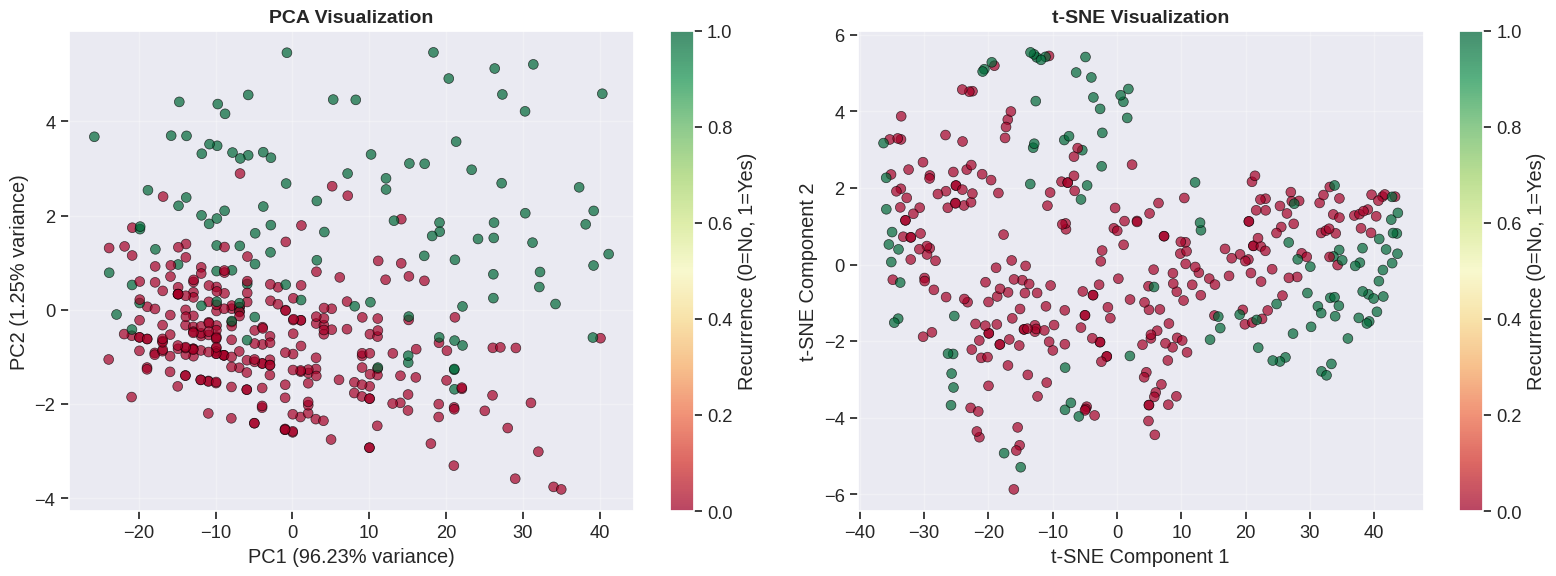

In [113]:

X_encoded = enc_df.drop(columns=[TARGET_COL])
y_encoded = enc_df[TARGET_COL]

pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_encoded)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
scatter1 = ax1.scatter(pca_result[:, 0], pca_result[:, 1],
                      c=y_encoded, cmap='RdYlGn', alpha=0.7,
                      edgecolors='black', linewidth=0.5, s=50)
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
ax1.set_title('PCA Visualization', fontsize=14, fontweight='bold')
ax1.grid(alpha=0.3)
plt.colorbar(scatter1, ax=ax1, label='Recurrence (0=No, 1=Yes)')

try:
    if len(df) > 500:
        sample_idx = np.random.choice(len(df), 500, replace=False)
        tsne_data = X_encoded.iloc[sample_idx]
        tsne_labels = y_encoded.iloc[sample_idx]
    else:
        tsne_data = X_encoded
        tsne_labels = y_encoded

    tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, n_iter=1000)
    tsne_result = tsne.fit_transform(tsne_data)

    ax2 = axes[1]
    scatter2 = ax2.scatter(tsne_result[:, 0], tsne_result[:, 1],
                          c=tsne_labels, cmap='RdYlGn', alpha=0.7,
                          edgecolors='black', linewidth=0.5, s=50)
    ax2.set_xlabel('t-SNE Component 1')
    ax2.set_ylabel('t-SNE Component 2')
    ax2.set_title('t-SNE Visualization', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)
    plt.colorbar(scatter2, ax=ax2, label='Recurrence (0=No, 1=Yes)')
except Exception as e:
    print(f" t-SNE plot error: {e}")

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/6_dimensionality_reduction.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()




### Class Imbalance Analysis

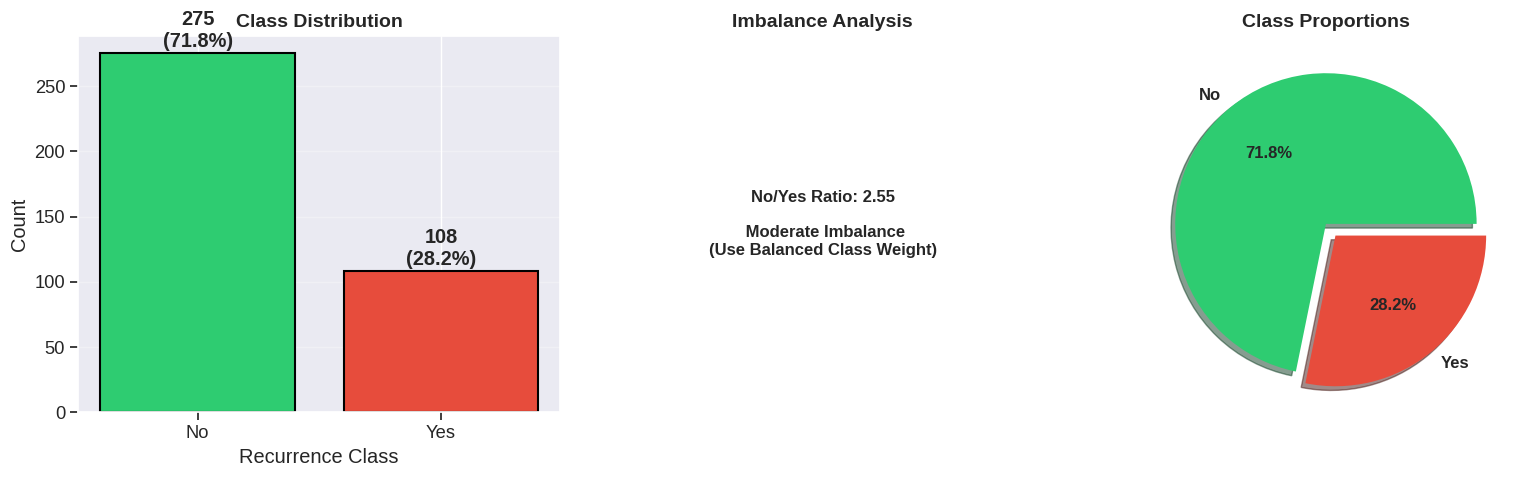

In [114]:


fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
counts = df[TARGET_COL].value_counts()
colors_bar = ['#2ecc71' if label == 'No' else '#e74c3c' for label in counts.index]
bars = ax.bar(counts.index, counts.values, color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_title('Class Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Recurrence Class')
ax.set_ylabel('Count')
ax.grid(axis='y', alpha=0.3)
for bar, count in zip(bars, counts.values):
    height = bar.get_height()
    percentage = (count/total)*100
    ax.text(bar.get_x() + bar.get_width()/2., height + 5,
            f'{count}\n({percentage:.1f}%)', ha='center', fontweight='bold')

ax = axes[1]
no_count = counts.get('No', 0)
yes_count = counts.get('Yes', 0)
ratio = no_count / yes_count if yes_count > 0 else float('inf')

imbalance_text = f'No/Yes Ratio: {ratio:.2f}\n\n'
if ratio > 5:
    imbalance_text += ' Severe Imbalance\n(Needs SMOTE/Random Sampling)'
elif ratio > 3:
    imbalance_text += ' High Imbalance\n(Consider Class Weights)'
elif ratio > 1.5:
    imbalance_text += ' Moderate Imbalance\n(Use Balanced Class Weight)'
else:
    imbalance_text += ' Balanced Dataset\n(No special handling needed)'

ax.text(0.5, 0.5, imbalance_text, horizontalalignment='center', verticalalignment='center',
        transform=ax.transAxes, fontsize=12, fontweight='bold')
ax.axis('off')
ax.set_title('Imbalance Analysis', fontsize=14, fontweight='bold')

ax = axes[2]
wedges, texts, autotexts = ax.pie(counts.values,
                                 labels=counts.index,
                                 autopct='%1.1f%%',
                                 colors=['#2ecc71', '#e74c3c'],
                                 explode=(0, 0.1),
                                 shadow=True,
                                 textprops={'fontsize': 12, 'weight': 'bold'})
ax.set_title('Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{OUT_DIR}/7_class_imbalance_analysis.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

What This Cell Does:
Purpose: Creates dimensionality reduction visualizations and class imbalance analysis.

Key Decisions & Rationale:

PCA (Principal Component Analysis) - Linear dimensionality reduction

Shows explained variance per component

Helps visualize if data is linearly separable

Color-coded by class - Green (No recurrence), Red (Recurrence)

t-SNE - Non-linear dimensionality reduction

Better at preserving local structure

More complex, handles non-linear patterns

Subsampling - Uses 500 samples if dataset is large (speeds up computation)

perplexity=30 - Controls balance between local and global structure

Class imbalance analysis (3 plots):

Bar chart - Shows class counts with percentages
Imbalance severity - Text-based analysis with recommendations:
Ratio > 5: Severe imbalance → Recommend SMOTE/Random Sampling
Ratio > 3: High imbalance → Consider Class Weights
Ratio > 1.5: Moderate imbalance → Use Balanced Class Weight
Ratio ≤ 1.5: Balanced → No special handling needed
Pie chart - Visual proportion
Why PCA + t-SNE? - Both provide different perspectives on data structure

